# Ames Housing - Exploratory Data Analysis & Data Cleaning

## Overview
This notebook performs:
1. Initial data exploration
2. Missing value analysis and handling
3. Outlier detection
4. Data cleaning and preprocessing
5. Saving processed data for modeling

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, mutual_info_regression
import joblib
import json
from pathlib import Path

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Create necessary directories
Path('../data/processed').mkdir(parents=True, exist_ok=True)
Path('../models').mkdir(parents=True, exist_ok=True)
Path('../reports/figures').mkdir(parents=True, exist_ok=True)
Path('../logs').mkdir(parents=True, exist_ok=True)

print("✅ Directories created successfully")

✅ Directories created successfully


## 1. Load Data

In [21]:
# Load the dataset
df = pd.read_csv('../data/raw/AmesHousing.csv')
print(f"Dataset Shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
df.head()

Dataset Shape: (2930, 82)
Columns: 82


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [22]:
# Basic information
print("=== Dataset Info ===")
df.info()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  Hous

In [23]:
# Summary statistics
print("=== Summary Statistics ===")
df.describe()

=== Summary Statistics ===


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


## 2. Target Variable Analysis

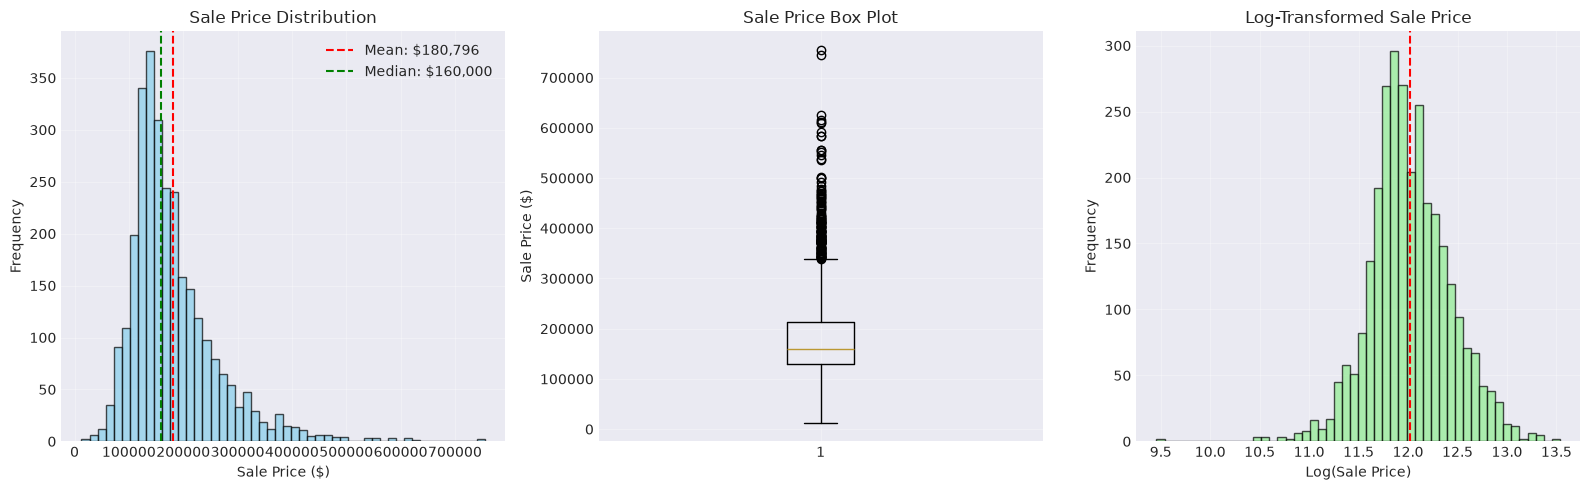

=== Target Statistics ===
count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [24]:
# Target distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram
axes[0].hist(df['SalePrice'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Sale Price Distribution')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['SalePrice'].mean(), color='red', linestyle='--', label=f'Mean: ${df["SalePrice"].mean():,.0f}')
axes[0].axvline(df['SalePrice'].median(), color='green', linestyle='--', label=f'Median: ${df["SalePrice"].median():,.0f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(df['SalePrice'])
axes[1].set_title('Sale Price Box Plot')
axes[1].set_ylabel('Sale Price ($)')
axes[1].grid(True, alpha=0.3)

# Log transformed
axes[2].hist(np.log(df['SalePrice']), bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[2].set_title('Log-Transformed Sale Price')
axes[2].set_xlabel('Log(Sale Price)')
axes[2].set_ylabel('Frequency')
axes[2].axvline(np.log(df['SalePrice']).mean(), color='red', linestyle='--')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/sale_price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("=== Target Statistics ===")
print(df['SalePrice'].describe())

## 3. Missing Values Analysis

In [25]:
# Missing values analysis
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(f"Total missing values: {missing.sum()}")
print(f"Columns with missing values: {len(missing)}")
print("\nMissing percentage by column:")
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)
print(missing_pct)

Total missing values: 15749
Columns with missing values: 27

Missing percentage by column:
Pool QC           99.556314
Misc Feature      96.382253
Alley             93.242321
Fence             80.477816
Mas Vnr Type      60.580205
Fireplace Qu      48.532423
Lot Frontage      16.723549
Garage Qual        5.426621
Garage Cond        5.426621
Garage Yr Blt      5.426621
Garage Finish      5.426621
Garage Type        5.358362
Bsmt Exposure      2.832765
BsmtFin Type 2     2.764505
Bsmt Cond          2.730375
Bsmt Qual          2.730375
BsmtFin Type 1     2.730375
Mas Vnr Area       0.784983
Bsmt Full Bath     0.068259
Bsmt Half Bath     0.068259
BsmtFin SF 1       0.034130
BsmtFin SF 2       0.034130
Electrical         0.034130
Total Bsmt SF      0.034130
Bsmt Unf SF        0.034130
Garage Area        0.034130
Garage Cars        0.034130
dtype: float64


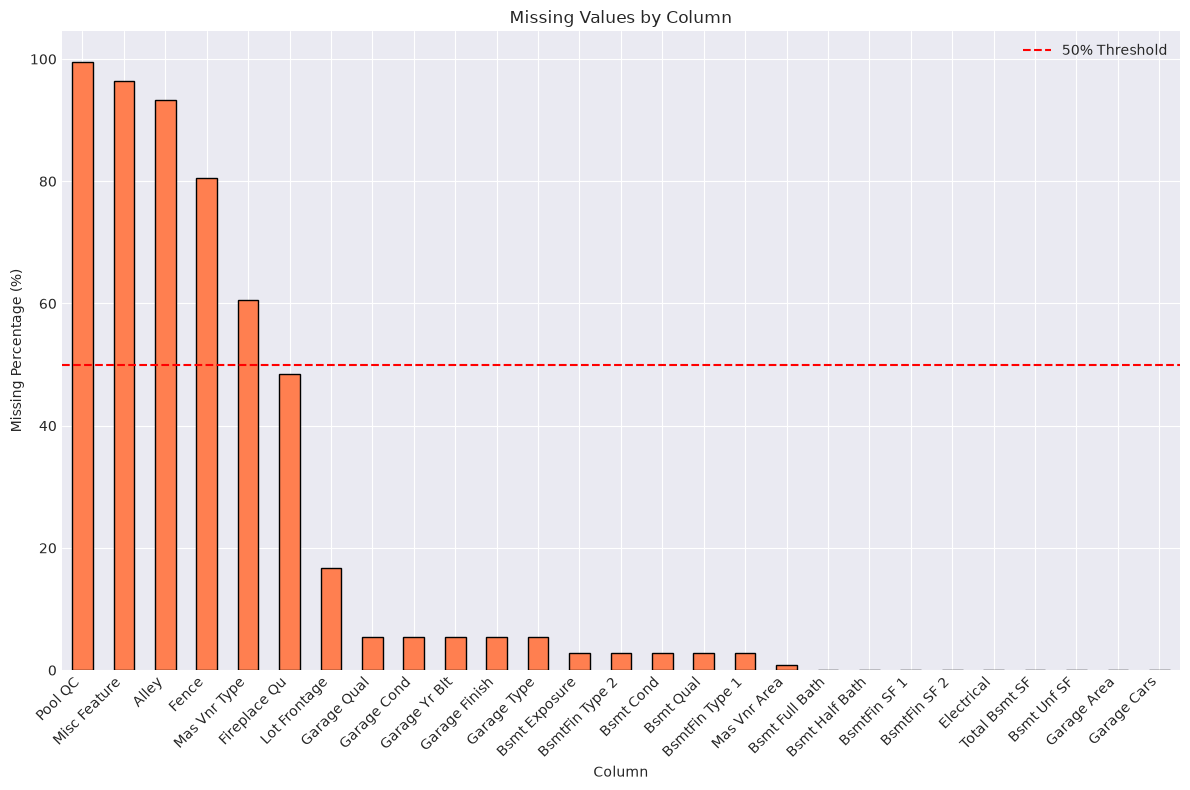

In [26]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(12, 8))
missing_pct.plot(kind='bar', color='coral', edgecolor='black')
ax.set_title('Missing Values by Column')
ax.set_xlabel('Column')
ax.set_ylabel('Missing Percentage (%)')
ax.axhline(y=50, color='red', linestyle='--', label='50% Threshold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Data Cleaning

In [27]:
def clean_ames_data(data):
    """Clean the Ames Housing dataset."""
    df_clean = data.copy()
    
    # Remove ID columns
    id_cols = [col for col in df_clean.columns if 'id' in col.lower() or 'pid' in col.lower()]
    if id_cols:
        df_clean = df_clean.drop(columns=id_cols)
        print(f"Removed ID columns: {id_cols}")
    
    # Handle categorical missing values
    categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
    for col in categorical_cols:
        if df_clean[col].isnull().any():
            df_clean[col] = df_clean[col].fillna('NA')
            print(f"Filled missing in {col} with 'NA'")
    
    # Handle numerical missing values
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col != 'SalePrice']
    
    dropped_cols = []
    for col in numeric_cols:
        missing_pct = df_clean[col].isnull().mean()
        if missing_pct > 0.5:
            # Drop columns with >50% missing
            df_clean = df_clean.drop(columns=[col])
            dropped_cols.append(col)
        elif missing_pct > 0:
            # Fill with median for remaining columns
            median_val = df_clean[col].median()
            df_clean[col] = df_clean[col].fillna(median_val)
    
    if dropped_cols:
        print(f"Dropped columns with >50% missing: {dropped_cols}")
    
    print(f"Cleaned shape: {df_clean.shape}")
    return df_clean

# Clean the data
df_clean = clean_ames_data(df)
print(f"\nMissing values remaining: {df_clean.isnull().sum().sum()}")

Removed ID columns: ['PID']
Filled missing in Alley with 'NA'
Filled missing in Mas Vnr Type with 'NA'
Filled missing in Bsmt Qual with 'NA'
Filled missing in Bsmt Cond with 'NA'
Filled missing in Bsmt Exposure with 'NA'
Filled missing in BsmtFin Type 1 with 'NA'
Filled missing in BsmtFin Type 2 with 'NA'
Filled missing in Electrical with 'NA'
Filled missing in Fireplace Qu with 'NA'
Filled missing in Garage Type with 'NA'
Filled missing in Garage Finish with 'NA'
Filled missing in Garage Qual with 'NA'
Filled missing in Garage Cond with 'NA'
Filled missing in Pool QC with 'NA'
Filled missing in Fence with 'NA'
Filled missing in Misc Feature with 'NA'
Cleaned shape: (2930, 81)

Missing values remaining: 0


## 5. Feature Engineering

In [28]:
def create_features(df):
    """Create new features."""
    df_new = df.copy()
    
    # 1. Age features
    df_new['Age'] = df_new['Yr Sold'] - df_new['Year Built']
    df_new['Age_At_Remodel'] = df_new['Year Remod/Add'] - df_new['Year Built']
    df_new['Is_Remodeled'] = (df_new['Age_At_Remodel'] > 0).astype(int)
    
    # 2. Area features
    df_new['Total_SF'] = df_new['1st Flr SF'] + df_new['2nd Flr SF']
    df_new['Total_Basement_SF'] = df_new['Total Bsmt SF']
    df_new['Total_Area'] = df_new['Total_SF'] + df_new['Total_Basement_SF']
    df_new['SF_per_Lot'] = df_new['Total_Area'] / (df_new['Lot Area'] + 1)
    
    # 3. Room features
    df_new['Total_Bathrooms'] = (df_new['Bsmt Full Bath'] + 
                                df_new['Bsmt Half Bath'] * 0.5 + 
                                df_new['Full Bath'] + 
                                df_new['Half Bath'] * 0.5)
    df_new['Total_Rooms'] = df_new['TotRms AbvGrd'] + df_new['Bedroom AbvGr']
    df_new['Bathroom_Per_Room'] = df_new['Total_Bathrooms'] / (df_new['TotRms AbvGrd'] + 1)
    
    # 4. Porch features
    df_new['Total_Porch_SF'] = (df_new['Wood Deck SF'] + 
                               df_new['Open Porch SF'] + 
                               df_new['Enclosed Porch'] + 
                               df_new['3Ssn Porch'] + 
                               df_new['Screen Porch'])
    df_new['Has_Porch'] = (df_new['Total_Porch_SF'] > 0).astype(int)
    df_new['Has_Pool'] = (df_new['Pool Area'] > 0).astype(int)
    df_new['Has_Fireplace'] = (df_new['Fireplaces'] > 0).astype(int)
    
    # 5. Garage features
    df_new['Has_Garage'] = (df_new['Garage Area'] > 0).astype(int)
    df_new['Garage_Cars_Per_Area'] = df_new['Garage Cars'] / (df_new['Garage Area'] + 1) * 100
    
    # 6. Quality features
    df_new['Quality_Score'] = df_new['Overall Qual'] * df_new['Overall Cond']
    df_new['Quality_Per_Room'] = df_new['Overall Qual'] / (df_new['TotRms AbvGrd'] + 1)
    
    # 7. Sale features
    df_new['Is_New_Construction'] = (df_new['Sale Condition'] == 'New').astype(int)
    df_new['Is_Abnormal_Sale'] = (df_new['Sale Condition'].isin(['Abnorml', 'AdjLand', 'Alloca'])).astype(int)
    
    # 8. Neighborhood features
    neighborhood_price = df_new.groupby('Neighborhood')['SalePrice'].median()
    df_new['Neighborhood_Price_Level'] = df_new['Neighborhood'].map(neighborhood_price)
    df_new['Neighborhood_Price_Level_Rank'] = df_new['Neighborhood_Price_Level'].rank(pct=True)
    
    print(f"New features created: {df_new.shape[1] - df.shape[1]}")
    return df_new

# Create features
df_featured = create_features(df_clean)
print(f"Final shape: {df_featured.shape}")

New features created: 22
Final shape: (2930, 103)


## 6. Encode Categorical Variables

In [29]:
# Encode categorical variables
def encode_categorical(df):
    df_encoded = df.copy()
    categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()
    label_encoders = {}
    
    for col in categorical_cols:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        label_encoders[col] = le
    
    print(f"Encoded {len(categorical_cols)} categorical variables")
    return df_encoded, label_encoders

df_encoded, label_encoders = encode_categorical(df_featured)
print(f"Encoded shape: {df_encoded.shape}")

Encoded 43 categorical variables
Encoded shape: (2930, 103)


## 7. Handle Skewed Features

In [30]:
# Transform skewed features
numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('SalePrice')

skewness = df_encoded[numeric_cols].skew()
highly_skewed = skewness[skewness > 1].index.tolist()
print(f"Highly skewed features ({len(highly_skewed)}): {highly_skewed[:10]}")

# Apply log transformation
df_transformed = df_encoded.copy()
power_transformers = {}

for col in highly_skewed:
    if (df_transformed[col] > 0).all():
        df_transformed[col] = np.log1p(df_transformed[col])
    else:
        pt = PowerTransformer(method='yeo-johnson')
        df_transformed[col] = pt.fit_transform(df_transformed[[col]])
        power_transformers[col] = pt

print("Features transformed successfully")

Highly skewed features (37): ['MS SubClass', 'Lot Frontage', 'Lot Area', 'Utilities', 'Land Slope', 'Condition 1', 'Condition 2', 'Bldg Type', 'Roof Style', 'Roof Matl']


Features transformed successfully


## 8. Feature Selection

In [31]:
# Split data
X = df_transformed.drop('SalePrice', axis=1)
y = df_transformed['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Feature selection using mutual information
selector = SelectKBest(score_func=mutual_info_regression, k=50)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_mask = selector.get_support()
selected_features = X_train.columns[selected_mask].tolist()

print(f"\nSelected {len(selected_features)} features out of {len(X_train.columns)}")

# Feature scores
feature_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

print("\nTop 20 features:")
print(feature_scores.head(20))

Training set: (2344, 102)
Test set: (586, 102)

Selected 50 features out of 102

Top 20 features:
                           Feature     Score
85                      Total_Area  0.610236
17                    Overall Qual  0.578669
12                    Neighborhood  0.540790
100       Neighborhood_Price_Level  0.532478
101  Neighborhood_Price_Level_Rank  0.532387
83                        Total_SF  0.482204
46                     Gr Liv Area  0.476613
96                   Quality_Score  0.428071
97                Quality_Per_Room  0.392085
19                      Year Built  0.388458
62                     Garage Area  0.386235
87                 Total_Bathrooms  0.379628
61                     Garage Cars  0.371228
80                             Age  0.356999
38                   Total Bsmt SF  0.350436
84               Total_Basement_SF  0.349364
89               Bathroom_Per_Room  0.340765
30                       Bsmt Qual  0.340390
43                      1st Flr SF  0.328607
53

## 9. Scale Features

In [32]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

print(f"Scaled training set: {X_train_scaled.shape}")
print(f"Scaled test set: {X_test_scaled.shape}")

Scaled training set: (2344, 50)
Scaled test set: (586, 50)


## 10. Save Processed Data and Artifacts

In [33]:
# Save processed data
processed_df = pd.DataFrame(X_train_scaled, columns=selected_features)
processed_df['SalePrice'] = y_train.values
processed_df.to_csv('../data/processed/ames_processed_train.csv', index=False)
print("✅ Training data saved to data/processed/ames_processed_train.csv")

test_df = pd.DataFrame(X_test_scaled, columns=selected_features)
test_df['SalePrice'] = y_test.values
test_df.to_csv('../data/processed/ames_processed_test.csv', index=False)
print("✅ Test data saved to data/processed/ames_processed_test.csv")

# Save complete processed dataset
X_all = scaler.transform(selector.transform(X))
df_complete = pd.DataFrame(X_all, columns=selected_features)
df_complete['SalePrice'] = y.values
df_complete.to_csv('../data/processed/ames_processed.csv', index=False)
print("✅ Complete processed data saved to data/processed/ames_processed.csv")

✅ Training data saved to data/processed/ames_processed_train.csv
✅ Test data saved to data/processed/ames_processed_test.csv
✅ Complete processed data saved to data/processed/ames_processed.csv


In [34]:
# Save artifacts for later use

# Save scaler
joblib.dump(scaler, '../models/scaler.pkl')
print("✅ Scaler saved to models/scaler.pkl")

# Save selected features
with open('../models/selected_features.json', 'w') as f:
    json.dump(selected_features, f, indent=2)
print("✅ Selected features saved to models/selected_features.json")

# Save feature scores
feature_scores.to_csv('../models/feature_importance.csv', index=False)
print("✅ Feature scores saved to models/feature_importance.csv")

# Save label encoders (for future use)
joblib.dump(label_encoders, '../models/label_encoders.pkl')
print("✅ Label encoders saved to models/label_encoders.pkl")

# Save power transformers
joblib.dump(power_transformers, '../models/power_transformers.pkl')
print("✅ Power transformers saved to models/power_transformers.pkl")

✅ Scaler saved to models/scaler.pkl
✅ Selected features saved to models/selected_features.json
✅ Feature scores saved to models/feature_importance.csv
✅ Label encoders saved to models/label_encoders.pkl
✅ Power transformers saved to models/power_transformers.pkl


In [35]:
# Save X_train, y_train, X_test, y_test for quick loading
training_data = {
    'X_train': X_train_scaled,
    'y_train': y_train.values,
    'X_test': X_test_scaled,
    'y_test': y_test.values,
    'feature_names': selected_features
}
joblib.dump(training_data, '../models/training_data.pkl')
print("✅ Training data saved to models/training_data.pkl")

✅ Training data saved to models/training_data.pkl


## 11. Correlation Analysis with Target

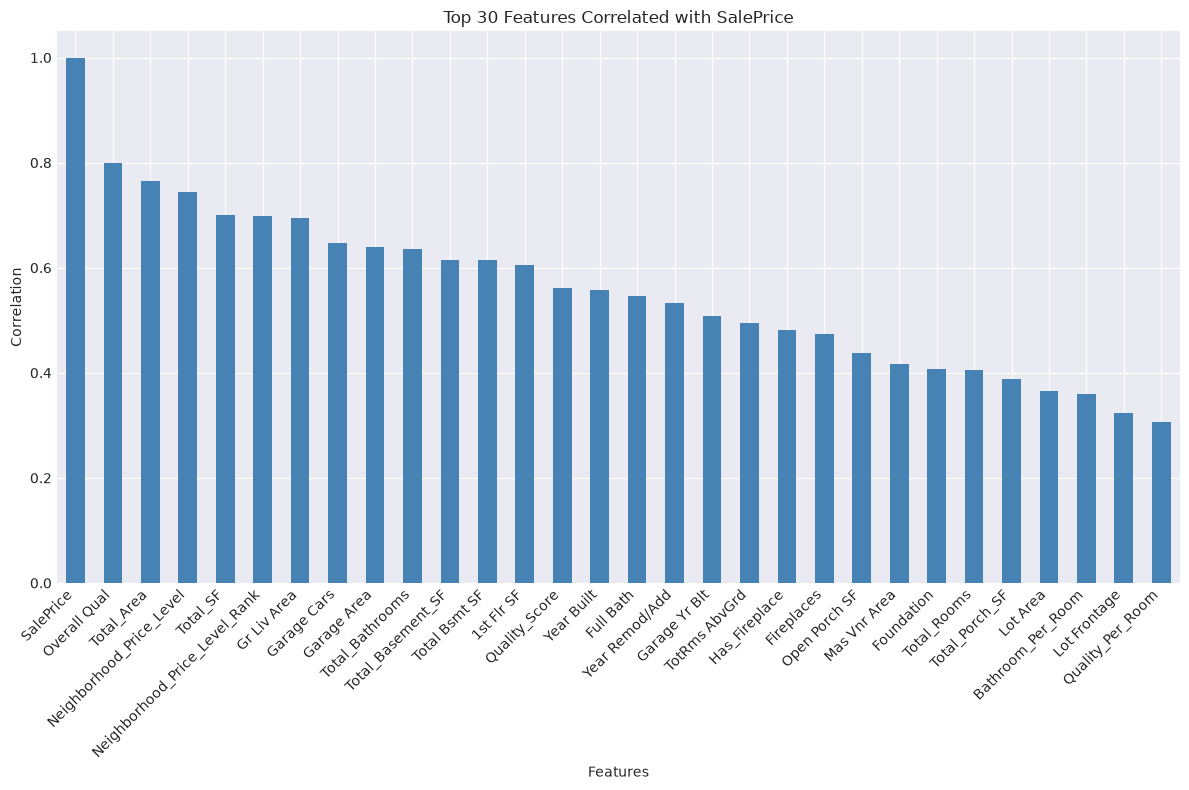


Top 10 correlations:
SalePrice                        1.000000
Overall Qual                     0.799262
Total_Area                       0.765162
Neighborhood_Price_Level         0.744066
Total_SF                         0.700325
Neighborhood_Price_Level_Rank    0.698874
Gr Liv Area                      0.695075
Garage Cars                      0.647812
Garage Area                      0.640381
Total_Bathrooms                  0.636175
Name: SalePrice, dtype: float64


In [36]:
# Correlation with target for final features
correlations = df_complete.corr()['SalePrice'].sort_values(ascending=False)

plt.figure(figsize=(12, 8))
correlations.head(30).plot(kind='bar', color='steelblue')
plt.title('Top 30 Features Correlated with SalePrice')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 correlations:")
print(correlations.head(10))

## 12. Summary

In [37]:
print("=" * 60)
print("EDA AND DATA CLEANING COMPLETE")
print("=" * 60)
print(f"\nOriginal shape: {df.shape}")
print(f"Final shape: {df_complete.shape}")
print(f"Features selected: {len(selected_features)}")
print(f"Training samples: {len(X_train_scaled)}")
print(f"Test samples: {len(X_test_scaled)}")

print("\nFiles generated:")
print("  - data/processed/ames_processed.csv")
print("  - data/processed/ames_processed_train.csv")
print("  - data/processed/ames_processed_test.csv")
print("  - models/scaler.pkl")
print("  - models/selected_features.json")
print("  - models/feature_importance.csv")
print("  - models/label_encoders.pkl")
print("  - models/power_transformers.pkl")
print("  - models/training_data.pkl")
print("  - reports/figures/sale_price_distribution.png")
print("  - reports/figures/missing_values.png")
print("  - reports/figures/correlation_analysis.png")

print("\n✅ All artifacts are ready for model training!")

EDA AND DATA CLEANING COMPLETE

Original shape: (2930, 82)
Final shape: (2930, 51)
Features selected: 50
Training samples: 2344
Test samples: 586

Files generated:
  - data/processed/ames_processed.csv
  - data/processed/ames_processed_train.csv
  - data/processed/ames_processed_test.csv
  - models/scaler.pkl
  - models/selected_features.json
  - models/feature_importance.csv
  - models/label_encoders.pkl
  - models/power_transformers.pkl
  - models/training_data.pkl
  - reports/figures/sale_price_distribution.png
  - reports/figures/missing_values.png
  - reports/figures/correlation_analysis.png

✅ All artifacts are ready for model training!


In [38]:
# Quick verification
print("\n=== Verification ===")
print(f"Processed data shape: {pd.read_csv('../data/processed/ames_processed.csv').shape}")
print(f"Scaler file exists: {Path('../models/scaler.pkl').exists()}")
print(f"Features file exists: {Path('../models/selected_features.json').exists()}")
print(f"Training data file exists: {Path('../models/training_data.pkl').exists()}")
print("\n✅ Everything is ready for Model Development notebook!")


=== Verification ===
Processed data shape: (2930, 51)
Scaler file exists: True
Features file exists: True
Training data file exists: True

✅ Everything is ready for Model Development notebook!
